# 1. 프로브를 만들기 전에 실험을 설계하기

**오늘의 주장 후보:** “모델 내부에 진실 방향이 있다.”
이것을 검증 가능한 좁은 문장으로 바꿔 보자:
“고정한 모델·층·token 위치의 activation으로 학습한 선형 분류기가, 학습에서 보지 않은 도시의 문장 참/거짓을 구분한다.”

`x ∈ R^d → score = wᵀx+b`. 지금 필요한 수학은 이 정도다. 중요한 것은 x, y, split을 어떻게 만들었는가다.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():
    candidates = [HERE / "study/linear_probes_ko", HERE / "ARENA_3.0/study/linear_probes_ko"]
    HERE = next(p for p in candidates if (p / "probe_lab.py").exists())
sys.path.insert(0, str(HERE))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from probe_lab import (group_split_indices, fit_mean_difference, fit_logistic_probe,
                       score_metrics, fit_train_pca, group_bootstrap_ci)
np.set_printoptions(precision=3, suppress=True)

## 실험 1 — 원본 행 단위 split이 충분한가?

“Paris is in France” / “Paris is in Brazil” / 두 문장의 부정형은 서로 독립된 사실이 아니다.
**도시 단위로 분할하고, 그 도시의 모든 파생 문장은 같은 분할에 둔다.**
pair split은 문장 암기 경로 하나를 줄인다. 모든 confound를 제거하는 것은 아니다.

**예측:** 같은 도시가 train/test 양쪽에 있을 때 어떤 정보로 정답을 맞출 수 있을까?

In [2]:
groups = np.repeat(np.arange(100), 2)
y = np.tile([0, 1], 100)
split = group_split_indices(groups, seed=42)
for a,b in [(split.train,split.val),(split.train,split.test),(split.val,split.test)]:
    assert set(groups[a]).isdisjoint(groups[b])
display(pd.DataFrame([{"split":k,"rows":len(getattr(split,k)),
                        "groups":len(np.unique(groups[getattr(split,k)]))}
                      for k in ["train","val","test"]]))

,split,rows,groups
0,train,120,60
1,val,40,20
2,test,40,20


## 실험 2 — validation에서 잘 맞아도 OOD에서 실패하는 이유

합성 activation의 첫 축에는 약한 label 신호, 둘째 축에는 강한 shortcut을 심는다.
train/validation에서는 shortcut이 정답과 함께 움직이고 OOD에서는 반대로 움직인다.
**LLM에서 관찰한 결과가 아니라, 실험의 식별 한계를 직접 보이는 반례다.**

먼저 예측: validation으로 C를 잘 골랐다면 이 OOD 실패도 막을 수 있을까?

In [3]:
rng = np.random.default_rng(42)
def make_data(n, shortcut_sign):
    y = np.tile([0,1], n//2)
    signal = 2*y-1
    X = rng.normal(size=(n, 12))
    X[:,0] += .8*signal
    X[:,1] = 2.5*shortcut_sign*signal + rng.normal(scale=.3,size=n)
    return X,y
Xtr,ytr=make_data(400,1)
Xva,yva=make_data(200,1)
Xod,yod=make_data(200,-1)
rows=[]
for C in [.01,.1,1]:
    p=fit_logistic_probe(Xtr,ytr,C=C)
    rows.append({"C":C,"validation_AUROC":score_metrics(yva,p.decision_function(Xva))["auroc"],
                 "OOD_AUROC":score_metrics(yod,p.decision_function(Xod))["auroc"]})
display(pd.DataFrame(rows))

,C,validation_AUROC,OOD_AUROC
0,0.01,1.0,0.0043
1,0.10,1.0,0.0000
2,1.00,1.0,0.0000


<details><summary>해석 힌트</summary>
Validation은 선택 편향을 막지만, validation에 없는 분포 변화까지 보장하지 않는다.
OOD AUROC가 0.5 아래여도 test를 본 뒤 score 부호를 뒤집어 성공이라고 보고하면 안 된다.
train의 positive label 의미를 고정한 채 실패 자체를 보고한다.
</details>

## 실험 3 — difference of means의 빠뜨리기 쉬운 절편

`w = μ₁ − μ₀`, `b = −wᵀ(μ₁+μ₀)/2`.
이 결정 경계는 두 평균의 중점을 지난다. `x @ w > 0`만 쓰면 activation 원점에 의존한다.
**연습:** x와 두 평균을 같은 벡터만큼 평행 이동할 때 판정이 왜 같아야 하는지 식으로 설명하자.

In [4]:
p = fit_mean_difference(Xtr,ytr)
shift = np.full(Xtr.shape[1],17.)
shifted = fit_mean_difference(Xtr+shift,ytr)
assert np.allclose(p.decision_function(Xva),shifted.decision_function(Xva+shift),atol=1e-7)
print("중점 보정 후 평행 이동에 불변:", True)
print("raw score는 확률이 아님. sigmoid를 취해도 자동으로 calibration되지는 않음.")

중점 보정 후 평행 이동에 불변: True
raw score는 확률이 아님. sigmoid를 취해도 자동으로 calibration되지는 않음.


## 실험 4 — 표준화된 LR 가중치를 residual stream에 더해도 되는가?

학습 좌표 `z=(x−μ)/σ`의 `w_scaled`와 원래 activation의 방향은 다르다.
`w_raw = w_scaled/σ`, `b_raw = b_scaled − w_rawᵀμ`.
예측 함수·cosine 비교·개입이 모두 같은 좌표를 쓰는지 검증한다.

**예측:** AUROC가 그대로인데 cosine 또는 steering 결과가 바뀔 수 있는 이유는?

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler=StandardScaler().fit(Xtr)
lr=LogisticRegression(C=.1,max_iter=2000,random_state=0).fit(scaler.transform(Xtr),ytr)
wraw=lr.coef_[0]/scaler.scale_
braw=lr.intercept_[0]-wraw@scaler.mean_
assert np.allclose(Xva@wraw+braw,lr.decision_function(scaler.transform(Xva)))
print("좌표 변환 최대 오차:",np.max(np.abs(Xva@wraw+braw-lr.decision_function(scaler.transform(Xva)))))

좌표 변환 최대 오차: 1.7763568394002505e-15


## 실험 5 — PCA 그림을 어느 정도 믿을까?

PCA는 큰 분산을 찾는다. class separation 목적함수가 아니다.
train에만 fit하고 held-out 점을 투영한다. 라벨 색칠은 지도 정보다.
PCA 2D에 안 보인다고 고차원 선형 분리가 없다는 결론도 성립하지 않는다.

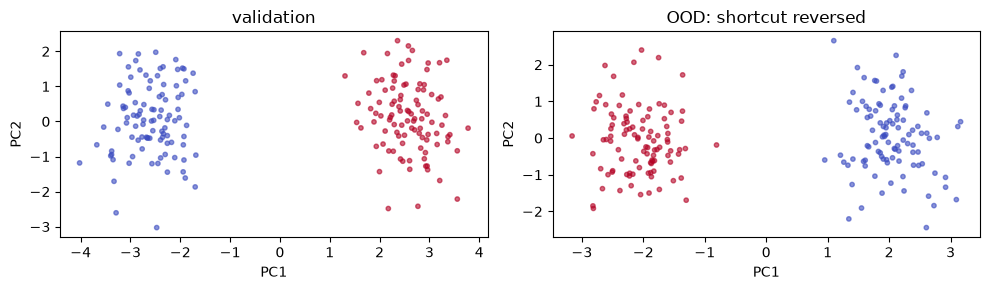

In [6]:
pca=fit_train_pca(Xtr,2)
fig,axs=plt.subplots(1,2,figsize=(10,3))
for ax,X,y,title in [(axs[0],Xva,yva,"validation"),(axs[1],Xod,yod,"OOD: shortcut reversed")]:
    Z=pca.transform(X)
    ax.scatter(Z[:,0],Z[:,1],c=y,cmap="coolwarm",s=10,alpha=.6)
    ax.set(title=title,xlabel="PC1",ylabel="PC2")
plt.tight_layout(); plt.show()

## 보조 반례 — 선형 probe 실패가 정보 부재를 뜻하지 않는 이유

XOR: 두 bit를 그대로 보유하지만, 둘의 XOR label은 단일 직선으로 나눌 수 없다.
비선형 probe가 성공하면 모델의 정보인지 probe가 새 계산을 했는지를 추가로 따져야 한다.
CCS의 consistency objective도 정답 의미를 유일하게 식별해 주지는 않는다.
지금은 CCS 구현보다 이 **식별 가능성 문제**를 이해하면 충분하다. 자세한 논쟁은 출처 문서의 선택 읽기.

In [7]:
Xxor=np.tile(np.array([[-1,-1],[-1,1],[1,-1],[1,1]]),(40,1))
yxor=(Xxor[:,0]*Xxor[:,1]<0).astype(int)
print("선형 LR:",score_metrics(yxor,fit_logistic_probe(Xxor,yxor).decision_function(Xxor)))
print("두 bit로 정답을 복원:", np.mean((Xxor[:,0]*Xxor[:,1]<0)==yxor))

선형 LR: {'auroc': 0.5, 'balanced_accuracy': 0.5, 'accuracy': 0.5}
두 bit로 정답을 복원: 1.0


## 다음 실험 사전 등록 — 아래를 채운 뒤 02로

1. 최종 test를 열기 전에 선택할 것: 층, LR의 C, threshold, token 위치 중 무엇인가?
2. 도시 이름 split과 다른 주제 OOD는 각각 어떤 주장을 검사하는가?
3. token 길이 baseline이 강하면 어떤 대조군을 추가할 것인가?
4. 높은 IID AUROC / 낮은 OOD AUROC를 한 문장으로 정직하게 보고하라.

In [8]:
preregistration = {
    "claim": "",
    "unit_of_split": "",
    "selection_data": "",
    "negative_control": "",
    "result_that_would_change_my_mind": "",
}